# 1. Libraries and paths

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO

In [4]:
input_path = "../general_input/"
train_path = input_path + "train/"
test_path = input_path + "test/"

train_fasta = train_path + "train_sequences.fasta"
test_fasta = test_path + "testsuperset.fasta"

# 2. Train exploration

In [5]:
# Check the number of genes in the training set
records = list(SeqIO.parse(train_fasta, "fasta"))
print(f"Number of genes in the training set: {len(records)}")

Number of genes in the training set: 82404


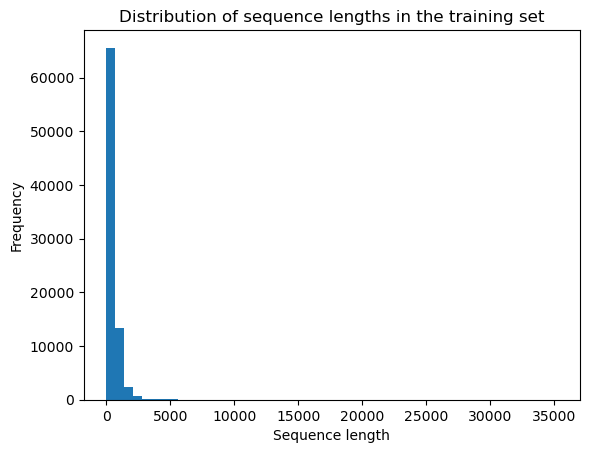

In [6]:
# Calculate the lengths of the sequences and print it in a histogram
lengths = [len(record.seq) for record in records]
plt.hist(lengths, bins=50)
plt.title("Distribution of sequence lengths in the training set")
plt.xlabel("Sequence length")
plt.ylabel("Frequency")
plt.show()

In [7]:
# Print the min and max lengths
print(f"Minimum sequence length: {min(lengths)}")
print(f"Maximum sequence length: {max(lengths)}")

Minimum sequence length: 3
Maximum sequence length: 35213


## 2.1. GO terms exploration

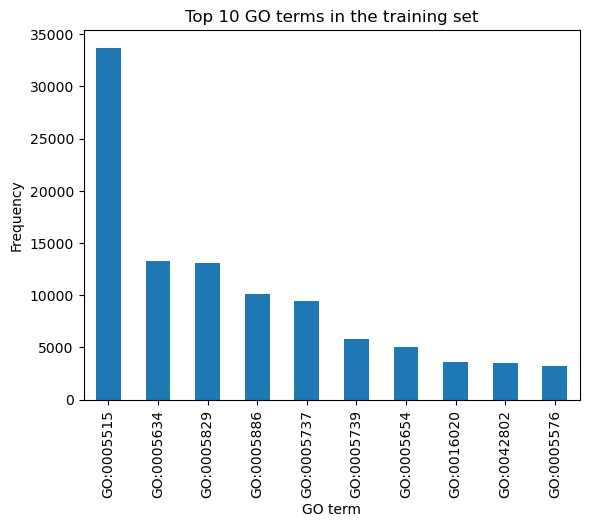

In [8]:
# Get the top 10 GO terms most frequent in the training set
go_annotations = pd.read_csv(train_path + "train_terms.tsv", sep="\t", header=None, names=["EntryID", "term", "aspect"])
top_go_terms = go_annotations["term"].value_counts().head(10)
# Plot the top 10 GO terms
top_go_terms.plot(kind="bar")
plt.title("Top 10 GO terms in the training set")
plt.xlabel("GO term")
plt.ylabel("Frequency")
plt.show()

In [9]:
# Read go-basic.obo file and search the top 10 GO terms definitions
import goatools.obo_parser as obo_parser

go_obo_path = train_path + "go-basic.obo"
go_terms_dict = {}

for go_term in obo_parser.GODag(go_obo_path).values():
    go_terms_dict[go_term.id] = go_term.name
for term in top_go_terms.index:
    print(f"{term}: {go_terms_dict.get(term, 'Definition not found')}")

../input/train/go-basic.obo: fmt(1.2) rel(2025-06-01) 43,448 Terms
GO:0005515: protein binding
GO:0005634: nucleus
GO:0005829: cytosol
GO:0005886: plasma membrane
GO:0005737: cytoplasm
GO:0005739: mitochondrion
GO:0005654: nucleoplasm
GO:0016020: membrane
GO:0042802: identical protein binding
GO:0005576: extracellular region


Apparently, all GO terms have general definitions. This makes sense.

## 2.2. Taxon exploration

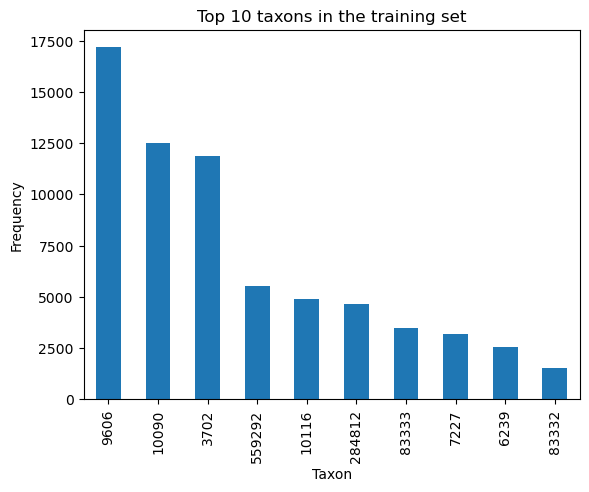

In [12]:
# Read the taxonomy file and explore the taxons present in the training set
taxon_annotations = pd.read_csv(train_path + "train_taxonomy.tsv", sep="\t", header=None, names=["EntryID", "taxon"])
top_taxons = taxon_annotations["taxon"].value_counts().head(10)
# Plot the top 10 taxons
top_taxons.plot(kind="bar")
plt.title("Top 10 taxons in the training set")
plt.xlabel("Taxon")
plt.ylabel("Frequency")
plt.show()

In [32]:
print(top_taxons)

taxon
9606      17162
10090     12508
3702      11863
559292     5520
10116      4909
284812     4636
83333      3466
7227       3201
6239       2540
83332      1530
Name: count, dtype: int64


In [14]:
print("The most frequent taxon is:", top_taxons.idxmax())
count_taxons = taxon_annotations["taxon"].value_counts()
print("The least frequent taxon is:", count_taxons.idxmin())

The most frequent taxon is: 9606
The least frequent taxon is: 4568


In [20]:
# See what species correspond to those taxons
import re

records = SeqIO.parse(train_fasta, "fasta")
taxon_to_species = {}

re_os = re.compile(r" OS=(.+?) OX=")
re_ox = re.compile(r" OX=(\d+)")

for record in records:
    header = record.description
    os_match = re_os.search(header)
    ox_match = re_ox.search(header)
    if os_match and ox_match:
        species = os_match.group(1)
        taxon = ox_match.group(1)
        taxon_to_species[int(taxon)] = species
print("Most frequent taxon species:", taxon_to_species.get(top_taxons.idxmax(), "Unknown"))
print("Least frequent taxon species:", taxon_to_species.get(count_taxons.idxmin(), "Unknown"))

Most frequent taxon species: Homo sapiens
Least frequent taxon species: Triticum monococcum


In [21]:
# Print the GO terms for the least frequent taxon
least_frequent_taxon = count_taxons.idxmin()
entries_in_least_frequent_taxon = taxon_annotations[taxon_annotations["taxon"] == least_frequent_taxon]["EntryID"]
go_terms_least_frequent_taxon = go_annotations[go_annotations["EntryID"].isin(entries_in_least_frequent_taxon)]["term"].unique()
print(f"GO terms for the least frequent taxon ({least_frequent_taxon}): {go_terms_least_frequent_taxon}")

GO terms for the least frequent taxon (4568): ['GO:0005737']


In [22]:
# Find the definition of those GO terms
for term in go_terms_least_frequent_taxon:
    print(f"{term}: {go_terms_dict.get(term, 'Definition not found')}")

GO:0005737: cytoplasm


# 3. Test exploration

In [23]:
# Number of genes in the test set
test_records = list(SeqIO.parse(test_fasta, "fasta"))
print(f"Number of genes in the test set: {len(test_records)}")

Number of genes in the test set: 224309


In [26]:
# Number of different taxons in the test set
test_taxon_annotations = pd.read_csv(test_path + "testsuperset-taxon-list.tsv", sep="\t", header=None, names=["taxon", "specie"])
num_test_taxons = test_taxon_annotations["taxon"].nunique()
print(f"Number of different taxons in the test set: {num_test_taxons}")

Number of different taxons in the test set: 8454


In [27]:
# Read the test fasta file and count the number of sequences per taxon
test_records = SeqIO.parse(test_fasta, "fasta")
dict_count_taxons = {}

for record in test_records:
    header = record.description
    taxon = header.split(" ")[1]
    if taxon in dict_count_taxons:
        dict_count_taxons[taxon] += 1
    else:
        dict_count_taxons[taxon] = 1

In [29]:
# Print the 10 most frequent taxons in the test set
sorted_taxons = sorted(dict_count_taxons.items(), key=lambda x: x[1], reverse=True)
print("10 most frequent taxons in the test set:")
for taxon, count in sorted_taxons[:10]:
    print(f"Taxon: {taxon}, Count: {count}")

10 most frequent taxons in the test set:
Taxon: 9606, Count: 20420
Taxon: 10090, Count: 17240
Taxon: 3702, Count: 16397
Taxon: 10116, Count: 8219
Taxon: 559292, Count: 6733
Taxon: 9913, Count: 6052
Taxon: 284812, Count: 5123
Taxon: 83333, Count: 4531
Taxon: 6239, Count: 4493
Taxon: 39947, Count: 4195


In [30]:
# Print the last 10 taxons in the test set
print("10 least frequent taxons in the test set:")
for taxon, count in sorted_taxons[-10:]:
    print(f"Taxon: {taxon}, Count: {count}")

10 least frequent taxons in the test set:
Taxon: 105606, Count: 1
Taxon: 2969, Count: 1
Taxon: 176265, Count: 1
Taxon: 81901, Count: 1
Taxon: 6347, Count: 1
Taxon: 42344, Count: 1
Taxon: 8374, Count: 1
Taxon: 309541, Count: 1
Taxon: 1274933, Count: 1
Taxon: 185214, Count: 1


In [31]:
# Print the name of the species for the most and least frequent taxons in the test set
print(f"Most frequent taxon species in test set: {test_taxon_annotations[test_taxon_annotations['taxon'] == sorted_taxons[0][0]]['specie'].values[0]}")
print(f"Least frequent taxon species in test set: {test_taxon_annotations[test_taxon_annotations['taxon'] == sorted_taxons[-1][0]]['specie'].values[0]}")

Most frequent taxon species in test set: Homo sapiens
Least frequent taxon species in test set: Liposcelis bostrychophila
